In [9]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


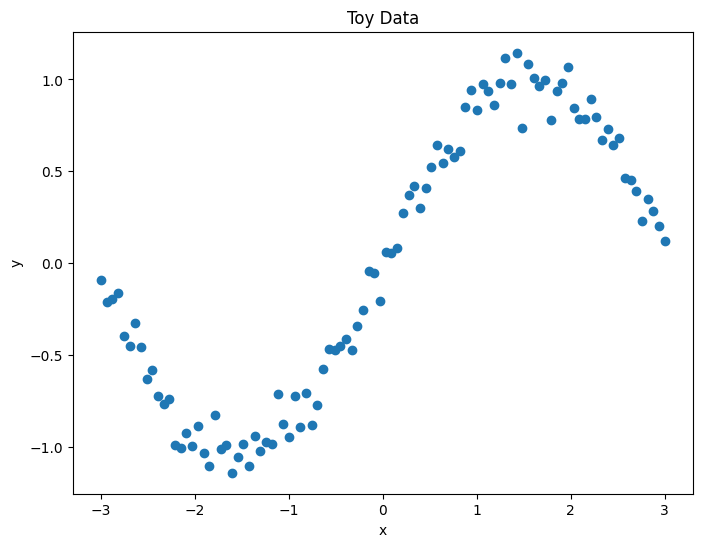

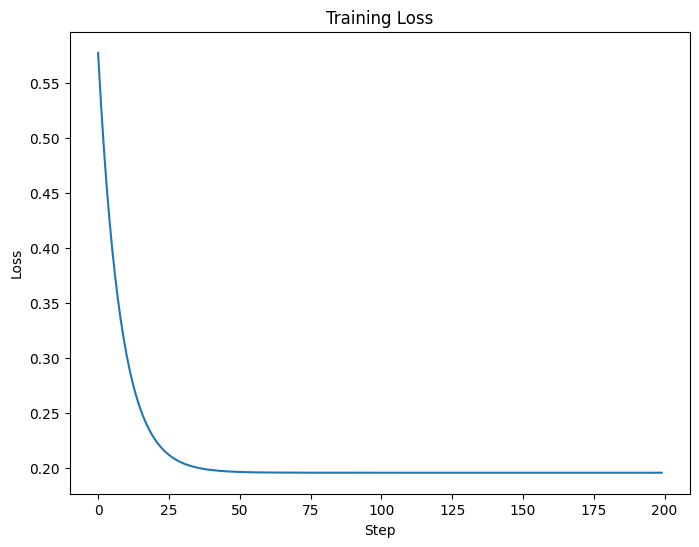

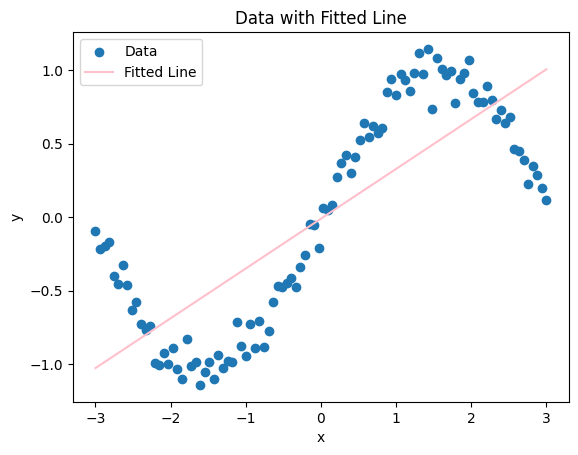

In [10]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.randn(100) * 0.1

#   Plot it.
plt.figure(figsize=(8, 6))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
losses = []
lr = 0.01
for step in range(200):
    y_hat = w * x + b

    loss = np.mean((y_hat - y) ** 2)  # MSE
    dw = np.mean(2 * (y_hat - y) * x)  # dLoss/dw  (derive this on paper!)
    db = np.mean(2 * (y_hat - y))  # dLoss/db
    w -= lr * dw
    b -= lr * db
    #   Record the loss at every step.
    losses.append(loss)
# TODO: Plot (a) the loss curve over the 200 steps, and
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
#           (b) the data with the fitted line on top.
plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x, w * x + b, color="pink", label="Fitted Line")
plt.title("Data with Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

**Student Reasoning — The single neuron 1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?**

![Derivative](image.jpeg)

**2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?**

The loss stops improving even though the predictions remain poor because a single neuron can only produce a linear (straight-line) function. The data, however, come from y = sin(x) + noise, which is fundamentally nonlinear. Gradient descent can only tune the two parameters w and b; it cannot alter the model’s functional form from a line into a curve. After enough iterations it simply converges to the best possible straight-line fit, and the loss plateaus. Capturing the true relationship therefore requires a model that can represent nonlinear mappings—for example a neural network with one or more hidden layers and nonlinear activation functions. The observed failure is classic underfitting: the model is too simple to express the pattern present in the data.

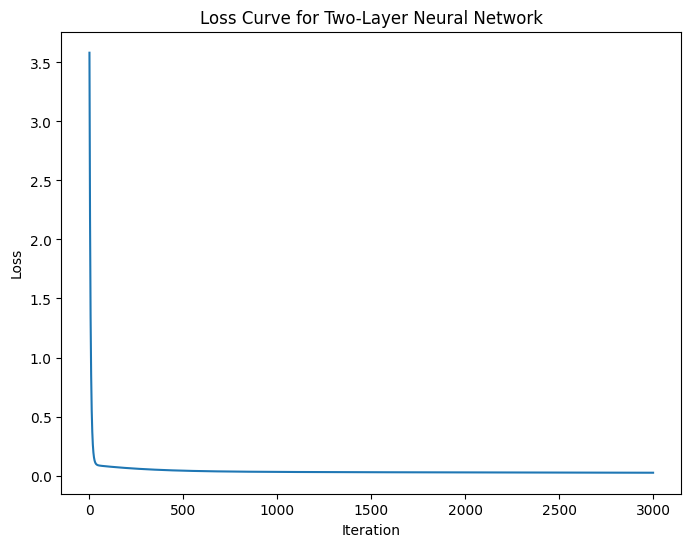

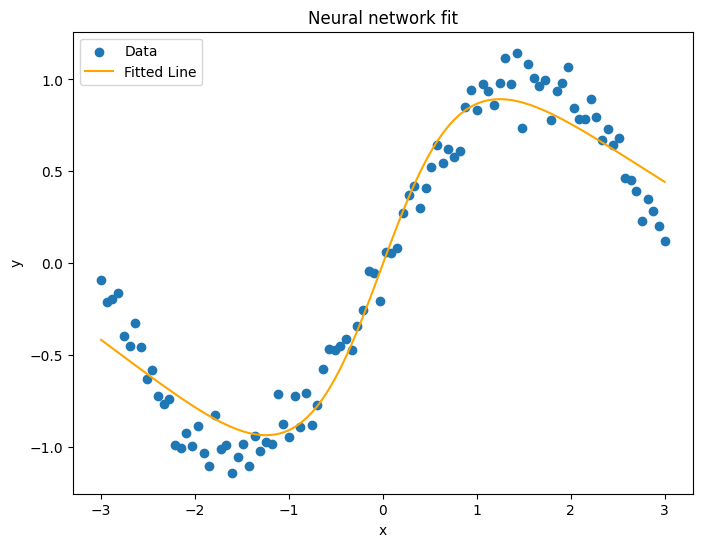

In [11]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
w1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

w2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ w1 + b1  # pre-activation, shape (100, 8)
h = np.tanh(z1)  # activation
y_hat = h @ w2 + b2  # output, shape (100, 1)
loss = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh = d_yhat @ w2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)  # derivative of tanh
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)
db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
w1 -= lr * dW1
b1 -= lr * db1
w2 -= lr * dW2
b2 -= lr * db2

losses = []

for i in range(3000):
    z1 = x @ w1 + b1
    h = np.tanh(z1)
    y_hat = h @ w2 + b2
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    w1 -= lr * dW1
    b1 -= lr * db1
    w2 -= lr * dW2
    b2 -= lr * db2
# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Curve for Two-Layer Neural Network")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="orange", label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural network fit")
plt.legend()
plt.show()


**Student Reasoning — Depth and activations**
**1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.**
Without activation functions the network is simply
z1=xW1+b1, y= ̂z1 W2+b2.

Substituting the first equation into the second gives
y ̂=(xW_1+b_1 ) W_2+b_2=x(W_1 W_2 )+(b_1 W_2+b_2 ),

which is just the single affine map y ̂=xW+bfor the effective weights W=W_1 W_2and bias b=b_1 W_2+b_2. The same reduction holds for any number of successive linear layers, so the whole stack remains a linear function. Depth alone therefore cannot increase the model’s ability to capture complex patterns; the non-linearity introduced by an activation function is what enables the network to represent non-linear relationships.


**2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)**
The eight hidden neurons function as feature extractors. Each neuron takes the input (x), applies its own set of weights and a bias, and generates a unique nonlinear output. Since the activation function is nonli
near, every neuron learns a distinct curved representation of the input. These eight learned representations are then combined by the output neuron to produce an approximation of the sine wave.

**3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?**
Backpropagation is the process of computing the gradients of the loss function with respect to each network parameter and propagating the error backward through the network so the weights and biases can be updated to reduce the loss.


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_74884/1356406537.py:18: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_74884/1356406537.py:24: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ w2.T
/tmp/ipykernel_74884/1356406537.py:25: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


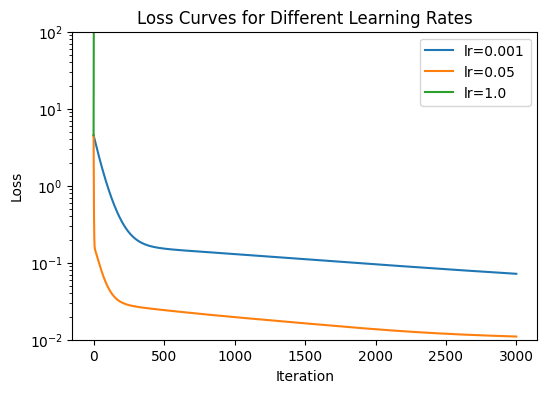

In [12]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.


def train_toy(lr, steps=3000):
    # Reset weights
    np.random.seed(42)
    w1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    w2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []
    for i in range(steps):
        z1 = x @ w1 + b1
        h = np.tanh(z1)
        y_hat = h @ w2 + b2
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ w2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        w1 -= lr * dW1
        b1 -= lr * db1
        w2 -= lr * dW2
        b2 -= lr * db2

    return losses


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
np.random.seed(42)
losses_0001 = train_toy(lr=0.001)
np.random.seed(42)
losses_005 = train_toy(lr=0.05)
np.random.seed(42)
losses_1 = train_toy(lr=1.0)


# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(6, 4))
plt.plot(losses_0001, label="lr=0.001")
plt.plot(losses_005, label="lr=0.05")
plt.plot(losses_1, label="lr=1.0")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.yscale("log")
plt.ylim(1e-2, 100)
plt.show()

**Student Reasoning — Learning rate Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?**
The learning rate controls the size of the parameter updates the model makes during training.

0.001: The loss decreases gradually because the parameter updates are very small, leading to slow learning.
0.05: The loss falls rapidly and then levels off, showing efficient and stable convergence.
1.0: The loss fluctuates or even increases because the updates are too large, causing the model to overshoot the optimal point.

A learning rate that is too high does not make the model learn faster. Instead, the large updates can repeatedly overshoot the minimum, causing unstable training and preventing the loss from converging.

In [13]:
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Load the obesity dataset from OBESITY_URL into a DataFrame called obesity
obesity = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).

# Binary yes/no columns
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
    if col in obesity.columns and not pd.api.types.is_numeric_dtype(obesity[col]):
        obesity[col] = obesity[col].astype(str).str.lower().map({"yes": 1, "no": 0})

# Gender (binary)
if "Gender" in obesity.columns and not pd.api.types.is_numeric_dtype(obesity["Gender"]):
    obesity["Gender"] = obesity["Gender"].replace(
        {"Male": 1, "Female": 0, "male": 1, "female": 0}
    )

# Ordinal
ordinal_cols = [
    col
    for col in ["CAEC", "CALC"]
    if col in obesity.columns and not pd.api.types.is_numeric_dtype(obesity[col])
]
if ordinal_cols:
    ordinal_encoder = OrdinalEncoder()
    obesity[ordinal_cols] = ordinal_encoder.fit_transform(obesity[ordinal_cols])

# Nominal
if "MTRANS" in obesity.columns:
    obesity = pd.get_dummies(obesity, columns=["MTRANS"], drop_first=True)

if "NObeyesdad" in obesity.columns and not pd.api.types.is_numeric_dtype(
    obesity["NObeyesdad"]
):
    label_encoder = LabelEncoder()
    obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,


X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.

# StandardScaler
scaler = StandardScaler()

# Fit ONLY on train, transform train, val, and test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:


# Convert to Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
# Wrap in TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Training: (1266, 19)
Validation: (422, 19)
Test: (423, 19)


/tmp/ipykernel_74884/2146011585.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  obesity["Gender"] = obesity["Gender"].replace(


Q1

CrossEntropyLoss requires integer class labels because it uses the class index directly to compute the loss rather than converting labels into one-hot encoded vectors. This approach is more memory-efficient and computationally faster.

Q2

Neural networks adjust their weights using gradients computed through gradient descent. The gradient of a weight is given by:
$$
\frac{\partial L}{\partial w} = 
\frac{\partial L}{\partial z} . x
$$
Since the gradient is multiplied by the input feature x, features with very large values produce large gradients. This can lead to unstable training, causing the optimization process to overshoot or oscillate instead of converging smoothly. Standardizing the features keeps gradient values on a similar scale, resulting in faster, more stable, and more reliable learning..


Q3

Setting shuffle=True randomly changes the order of the training samples at the beginning of every epoch. This prevents the model from memorizing patterns related to the sequence of the data and helps it generalize better to unseen examples.

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module)
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        h1, h2 = hidden_sizes

        # Layer 1: Input to First Hidden Layer
        self.fc1 = nn.Linear(input_dim, h1)
        self.relu1 = nn.ReLU()

        # Layer 2: First Hidden Layer to Second Hidden Layer
        self.fc2 = nn.Linear(h1, h2)
        self.relu2 = nn.ReLU()

        # Layer 3: Second Hidden Layer to Output Logits
        self.out = nn.Linear(h2, n_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.out(x)
        return x


# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_scaled.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(
    DEVICE
)

print(model)


# TODO: Count trainable parameters:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")

# Hand-calculated parameter count for Layer 1
layer1_params_hand = input_dim * 64 + 64
print(f"Hand-calculated Layer 1 Parameters: {layer1_params_hand}")

FeedForwardNet(
  (fc1): Linear(in_features=19, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (out): Linear(in_features=32, out_features=7, bias=True)
)

Total Trainable Parameters: 3591
Hand-calculated Layer 1 Parameters: 1280




*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*

* *Layer 1 (fc1):* 
  * Weights: $19 \times 64$
  * Biases: $64$
  * Subtotal: $1216 + 64 = 1,280$ parameters.

* *Layer 2 (fc2):*
  * Weights: $64 \times 32 = 2,048$
  * Biases: $32$
  * Subtotal: $2,048 + 32 = 2,080$ parameters.

* *Output Layer (out):*
  * Weights: $32 \times 7 = 224$
  * Biases: $7$
  * Subtotal: $224 + 7 = 231$ parameters.

* *Total Parameters:* $1,280 + 2,080 + 231 = 3591$.
This matches the total output given by sum(p.numel() for p in model.parameters() if p.requires_grad).

*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*


A major benefit of ReLU ($\max(0, x)$) is that it helps reduce the vanishing gradient problem by allowing positive input values to maintain a gradient of 1, which enables effective weight updates during training. 

Unlike tanh, which compresses large input values into flat regions where the gradient becomes nearly zero, ReLU maintains a constant derivative of 1 for all positive inputs. This allows gradients to pass through deep network layers without becoming smaller, helping the model train more efficiently and remain stable.

*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*


If the non-linear ReLU activation functions are removed, the entire neural network becomes equivalent to a simple linear transformation of the input data.

Because multiplying multiple weight matrices together results in a single combined matrix ($W_3 \cdot W_2 \cdot W_1 = W_{net}$),a deep network without activation functions cannot learn complex patterns or representations. Instead, it behaves like a basic linear model, such as linear regression or logistic regression.

Epoch 01/50 | Train Loss: 1.8885 - Acc: 0.2299 | Val Loss: 1.8002 - Acc: 0.3555
Epoch 02/50 | Train Loss: 1.6564 - Acc: 0.4265 | Val Loss: 1.5190 - Acc: 0.5047
Epoch 03/50 | Train Loss: 1.3209 - Acc: 0.5719 | Val Loss: 1.1916 - Acc: 0.6019
Epoch 04/50 | Train Loss: 1.0306 - Acc: 0.6509 | Val Loss: 0.9761 - Acc: 0.6659
Epoch 05/50 | Train Loss: 0.8456 - Acc: 0.7022 | Val Loss: 0.8558 - Acc: 0.7038
Epoch 06/50 | Train Loss: 0.7098 - Acc: 0.7520 | Val Loss: 0.7508 - Acc: 0.7607
Epoch 07/50 | Train Loss: 0.6061 - Acc: 0.7994 | Val Loss: 0.6854 - Acc: 0.7891
Epoch 08/50 | Train Loss: 0.5290 - Acc: 0.8318 | Val Loss: 0.6282 - Acc: 0.7915
Epoch 09/50 | Train Loss: 0.4626 - Acc: 0.8594 | Val Loss: 0.5855 - Acc: 0.8199
Epoch 10/50 | Train Loss: 0.4119 - Acc: 0.8689 | Val Loss: 0.5488 - Acc: 0.8507
Epoch 11/50 | Train Loss: 0.3676 - Acc: 0.8831 | Val Loss: 0.5202 - Acc: 0.8531
Epoch 12/50 | Train Loss: 0.3268 - Acc: 0.8981 | Val Loss: 0.5118 - Acc: 0.8673
Epoch 13/50 | Train Loss: 0.2948 - Acc: 

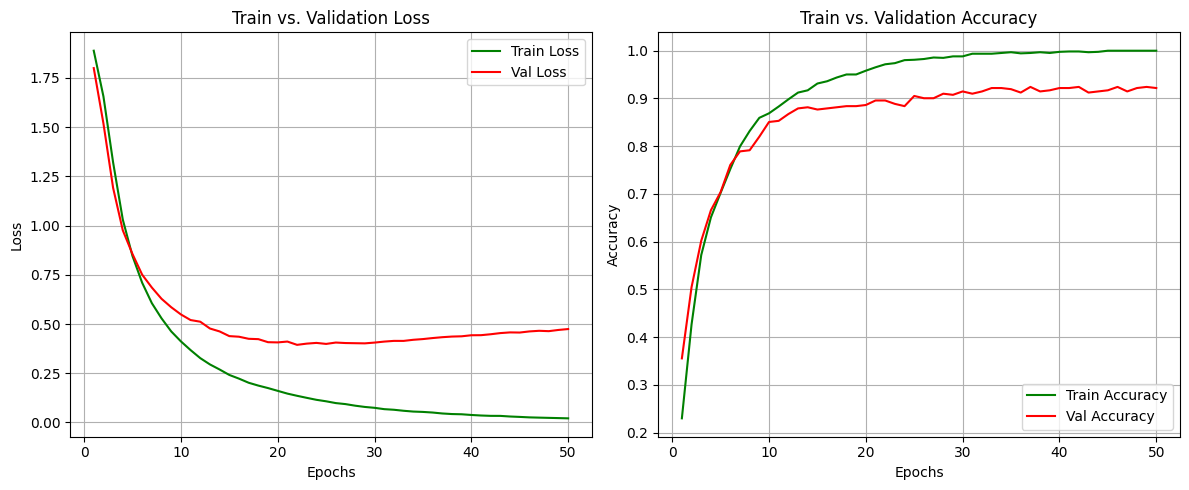

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # or SGD — justify

# Tracking history
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

EPOCHS = 50
best_val_acc = 0.0
best_model_weights = None

# TODO: Train for at least 50 epochs. Each epoch:

for epoch in range(1, EPOCHS + 1):
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += xb.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    #   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
    #   3. Append everything to history lists; print a one-line summary per epoch.
    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    # Append everything to history lists
    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    # Print summary per epoch
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}"
    )

    # TODO: Save the best model (highest validation accuracy):
    # Track and save best model weights
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "ffn_best.pt")


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} (Saved to ffn_best.pt)")

# --- TODO: Plot Loss and Accuracy Curves ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history["train_loss"], label="Train Loss", color="green")
plt.plot(range(1, EPOCHS + 1), history["val_loss"], label="Val Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs. Validation Loss")
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(
    range(1, EPOCHS + 1), history["train_acc"], label="Train Accuracy", color="green"
)
plt.plot(range(1, EPOCHS + 1), history["val_acc"], label="Val Accuracy", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train vs. Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Student Reasoning — Training

*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?*

Forward pass: logits = model(xb.to(DEVICE)) performs the forward propagation by passing the input through each layer, where matrix multiplications and activation functions generate the output predictions, similar to the manual forward calculations in NumPy.

Gradient computation: loss.backward() carries out backpropagation, computing the gradients of the loss with respect to every trainable parameters $\frac{\partial L}{\partial W}$ across all network parameters).

Weight update: optimizer.step() adjusts the model's weights using the calculated gradients according to the optimization rule, for example:, e.g., $W = W - \alpha \cdot \frac{\partial L}{\partial W}$) where α is the learning rate.

*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.*

The model shows signs of slight overfitting in the later epochs, but it still maintains strong validation performance overall.

Evidence:
At around Epoch 25, the model achieves a strong validation result with a validation loss of 0.3990 and a validation accuracy of 90.52%.

By Epoch 50, the training accuracy reaches 100.00% with a very low training loss of 0.0209, while the validation loss increases to 0.4745 and validation accuracy decreases slightly to 92.18%.

The increasing gap between the perfect training accuracy and the slower improvement in validation performance suggests that the model starts learning training-specific patterns in the later epochs. However, the validation accuracy remains high, indicating that the overfitting is limited. Saving the best weights using ffn_best.pt ensures that the model checkpoint with the strongest validation performance is used for final testing.

*3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?*
By default, PyTorch accumulates gradients each time .backward() is called rather than replacing the previous ones.

If optimizer.zero_grad() is not executed before processing each mini-batch, the gradients from earlier batches continue to accumulate. As a result, the updates become excessively large and inaccurate, causing the model's parameters to move in the wrong direction and preventing the training process from converging properly.

Experiment A (Capacity)


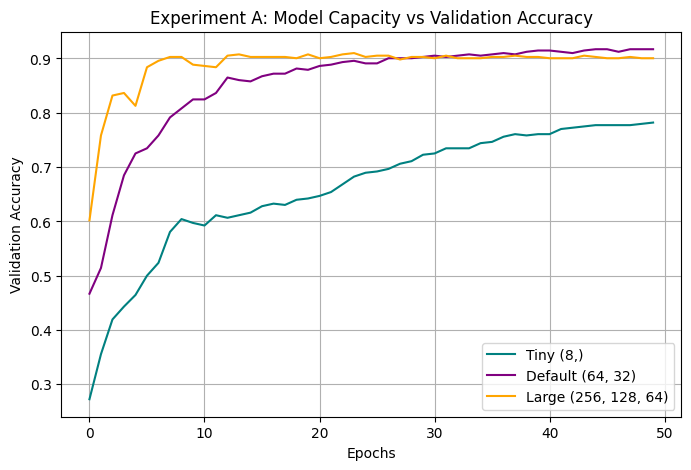

Experiment B (Learning Rate)


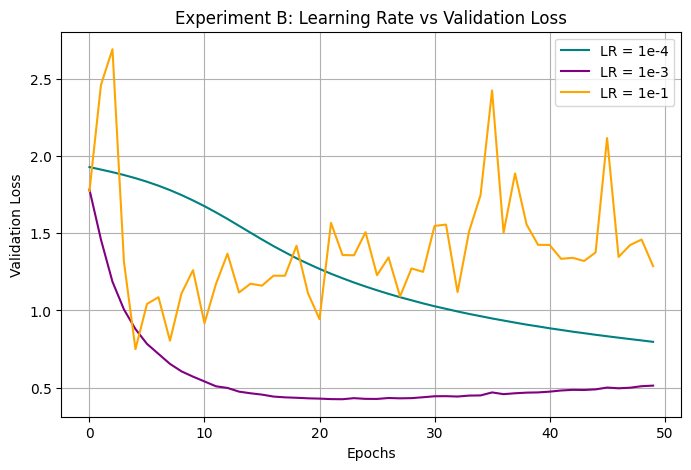

Experiment C (Dropout Regularization)


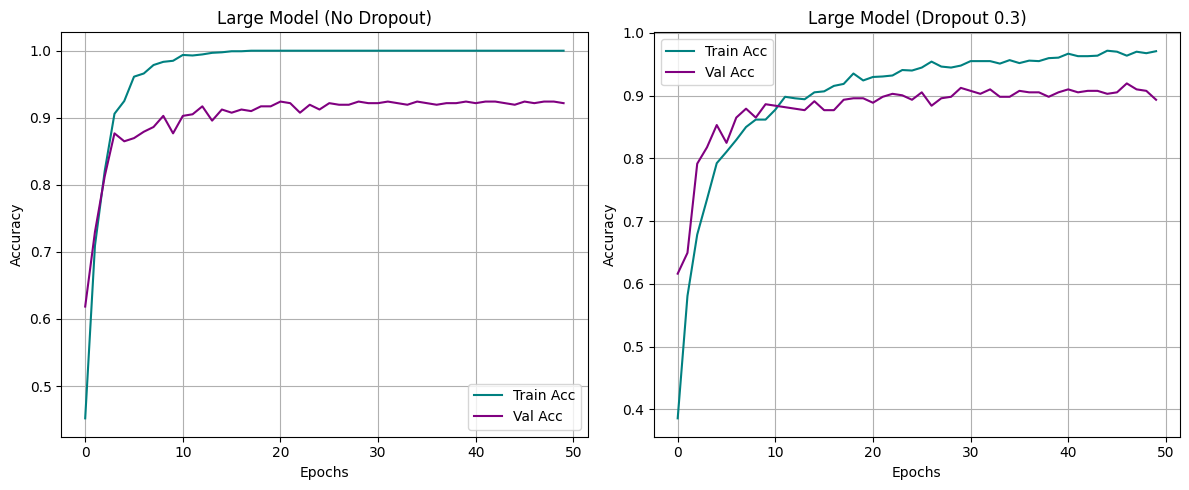

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# Refactored FeedForwardNet Class with Dropout
class FlexibleFeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Generic Training Experiment Function
def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    # Create DataLoaders with specified batch size
    train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Instantiate model & optimizer
    model = FlexibleFeedForwardNet(
        input_dim=X_train_scaled.shape[1],
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout=dropout,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        t_loss, t_corr, t_total = 0.0, 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            t_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            t_corr += (preds == yb).sum().item()
            t_total += xb.size(0)

        # Validation Phase
        model.eval()
        v_loss, v_corr, v_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)

                v_loss += loss.item() * xb.size(0)
                preds = torch.argmax(logits, dim=1)
                v_corr += (preds == yb).sum().item()
                v_total += xb.size(0)

        history["train_loss"].append(t_loss / t_total)
        history["train_acc"].append(t_corr / t_total)
        history["val_loss"].append(v_loss / v_total)
        history["val_acc"].append(v_corr / v_total)

    return history


# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
print("Experiment A (Capacity)")
hist_tiny = run_experiment(hidden_sizes=(8,), epochs=50)
hist_default = run_experiment(hidden_sizes=(64, 32), epochs=50)
hist_large = run_experiment(hidden_sizes=(256, 128, 64), epochs=50)

plt.figure(figsize=(8, 5))
plt.plot(hist_tiny["val_acc"], label="Tiny (8,)", color="teal")
plt.plot(hist_default["val_acc"], label="Default (64, 32)", color="purple")
plt.plot(hist_large["val_acc"], label="Large (256, 128, 64)", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Model Capacity vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
print("Experiment B (Learning Rate)")
hist_lr_low = run_experiment(lr=1e-4, epochs=50)
hist_lr_mid = run_experiment(lr=1e-3, epochs=50)
hist_lr_high = run_experiment(lr=1e-1, epochs=50)

plt.figure(figsize=(8, 5))
plt.plot(hist_lr_low["val_loss"], label="LR = 1e-4", color="teal")
plt.plot(hist_lr_mid["val_loss"], label="LR = 1e-3", color="purple")
plt.plot(hist_lr_high["val_loss"], label="LR = 1e-1", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
print("Experiment C (Dropout Regularization)")
hist_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0, epochs=50)
hist_with_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3, epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Without Dropout
axes[0].plot(hist_no_dropout["train_acc"], label="Train Acc", color="teal")
axes[0].plot(hist_no_dropout["val_acc"], label="Val Acc", color="red")
axes[0].set_title("Large Model (No Dropout)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# With Dropout
axes[1].plot(hist_with_dropout["train_acc"], label="Train Acc", color="teal")
axes[1].plot(hist_with_dropout["val_acc"], label="Val Acc", color="red")
axes[1].set_title("Large Model (Dropout 0.3)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Student Reasoning — Experiments

*1. Capacity*
Not necessarily. A larger network learns faster during training, but the default (64, 32) architecture usually delivers equivalent or superior test performance. Scaling up past this point leads to diminishing returns, mainly causing the model to overfit faster as training loss plunges while validation loss stalls.

*2. Learning rate*
Absolutely. They align perfectly with the three standard learning rate scenarios:
1e-4 (too small): Progresses much too slowly, leaving the model underfitted after 50 epochs.
1e-3 (optimal): Steadily converges to minimal loss and strong accuracy.
1e-1 (too large): Instable or exploding training that fails to converge.

*3. Regularization*
Dropout minimized overfitting, closing the gap between training and validation accuracy. By randomly shutting off neurons during training, it prevents the network from relying on specific nodes and forces it to build robust, redundant feature representations.